# IMDb Sentiment Analysis - Comprehensive EDA

This notebook performs exploratory data analysis for the IMDb sentiment dataset used in the MLOps pipeline.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

TRAIN_PATH = "../Datasets/HFData/Raw/train.csv"
TEST_PATH = "../Datasets/HFData/Raw/test.csv"

PROCESSED_DIR = "../Datasets/HFData/Processed"


df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Shape:", df.shape)
df.head()


Shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## Dataset Overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [7]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 31.2 MB


In [8]:
df.describe(include="all")

,text,label
count,25000,25000.00000
unique,24904,NaN
top,This show comes up with interesting locations ...,NaN
freq,3,NaN
mean,NaN,0.50000
std,NaN,0.50001
min,NaN,0.00000
25%,NaN,0.00000
50%,NaN,0.50000
75%,NaN,1.00000


In [9]:
test_df.describe(include="all")

,text,label
count,25000,25000.00000
unique,24801,NaN
top,Loved today's show!!! It was a variety and not...,NaN
freq,5,NaN
mean,NaN,0.50000
std,NaN,0.50001
min,NaN,0.00000
25%,NaN,0.00000
50%,NaN,0.50000
75%,NaN,1.00000


## Missing Values

In [10]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [11]:
test_df.isnull().sum()

text     0
label    0
dtype: int64

## Duplicate Records

In [12]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

test_duplicates = test_df.duplicated().sum()
print("Duplicate rows in test set:", test_duplicates)

Duplicate rows: 96
Duplicate rows in test set: 199


## Text Preprocessing

In [13]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[\W_]+', ' ', text)
    text = text.replace("<br />", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['text'] = df['text'].apply(preprocess_text)
df.drop_duplicates(inplace=True)
print('Train set text column preprocessed.')

test_df['text'] = test_df['text'].apply(preprocess_text)
test_df.drop_duplicates(inplace=True)
print('Test set text column preprocessed.')

Train set text column preprocessed.
Test set text column preprocessed.


In [ ]:
# Recheck for duplicates after text preprocessing
duplicates_after_preprocessing = df.duplicated().sum()
print("Duplicate rows after preprocessing:", duplicates_after_preprocessing)

# Recheck for missing values after text preprocessing
missing_values_after_preprocessing = df.isnull().sum().sum()
print("Missing values after preprocessing:", missing_values_after_preprocessing)


# Recheck for duplicates in test set after text preprocessing
test_duplicates_after_preprocessing = test_df.duplicated().sum()
print("Duplicate rows in test set after preprocessing:", test_duplicates_after_preprocessing)   

missing_values_test_after_preprocessing = test_df.isnull().sum().sum()
print("Missing values in test set after preprocessing:", missing_values_test_after_preprocessing)

Duplicate rows after preprocessing: 0
Missing values after preprocessing: 0
Duplicate rows in test set after preprocessing: 0
Missing values in test set after preprocessing: 0


## Class Distribution

label
1    12470
0    12432
Name: count, dtype: int64


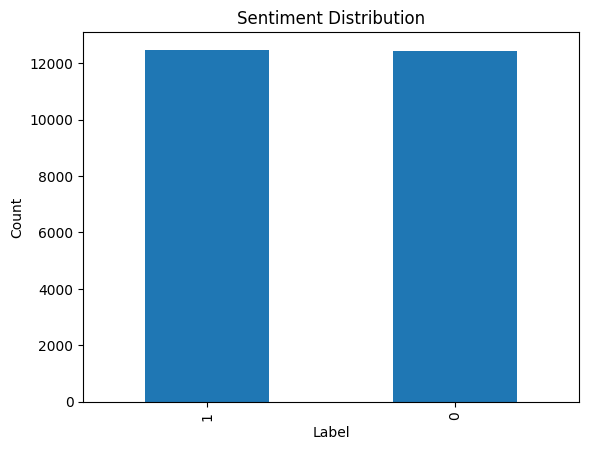

In [15]:
class_counts = df["label"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


## Label Percentages

In [16]:
(df["label"].value_counts(normalize=True) * 100).round(2)

label
1    50.08
0    49.92
Name: proportion, dtype: float64

## Review Length Analysis (Words)

In [17]:
df["review_length_words"] = df["text"].astype(str).str.split().str.len()

df["review_length_words"].describe()


count    24902.000000
mean       242.524616
std        180.056550
min         10.000000
25%        132.000000
50%        181.000000
75%        295.000000
max       2525.000000
Name: review_length_words, dtype: float64

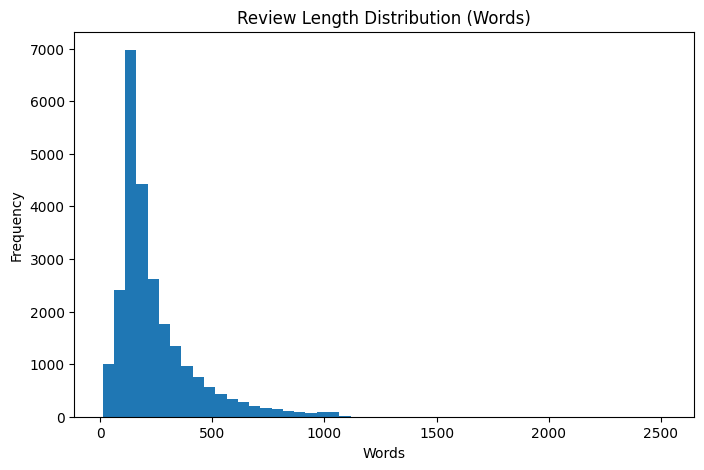

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length_words"], bins=50)
plt.title("Review Length Distribution (Words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


## Review Length Analysis (Characters)

In [19]:
df["review_length_chars"] = df["text"].astype(str).str.len()

df["review_length_chars"].describe()


count    24902.000000
mean      1281.677496
std        970.872918
min         51.000000
25%        680.000000
50%        947.000000
75%       1559.000000
max      13401.000000
Name: review_length_chars, dtype: float64

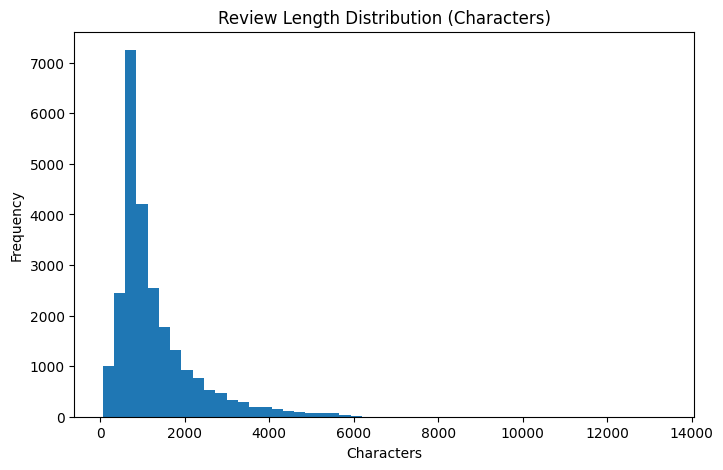

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length_chars"], bins=50)
plt.title("Review Length Distribution (Characters)")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


## Token Length Analysis for DistilBERT

In [21]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_df = df.sample(min(2000, len(df)), random_state=42)

token_lengths = sample_df["text"].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

token_lengths.describe()


/Users/karansingh/Assingments/MLOPs/MLOPS-Asgn-2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


count    2000.000000
mean      256.749000
std       196.848187
min        12.000000
25%       140.000000
50%       186.500000
75%       312.250000
max      2769.000000
Name: text, dtype: float64

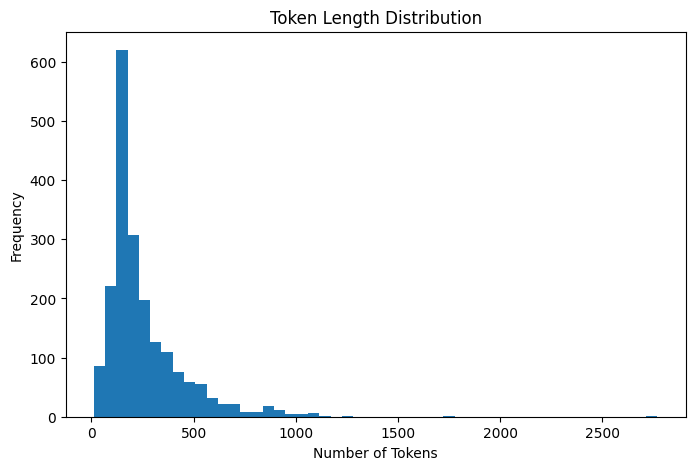

In [22]:
plt.figure(figsize=(8,5))
plt.hist(token_lengths, bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


## Percentage of Reviews Exceeding 256 Tokens

In [23]:
pct = (token_lengths > 256).mean() * 100
print(f"Reviews exceeding 256 tokens: {pct:.2f}%")

Reviews exceeding 256 tokens: 33.80%


## Positive vs Negative Length Comparison

In [24]:
df.groupby("label")["review_length_words"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12432.0,239.926560,173.224810,10.0,133.0,181.0,289.0,1600.0
1,12470.0,245.114755,186.589639,12.0,130.0,180.0,301.0,2525.0


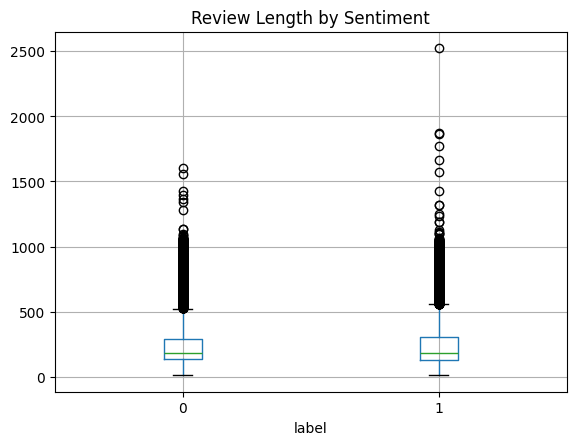

In [25]:
df.boxplot(column="review_length_words", by="label")
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.show()


## Sample Positive Review

In [26]:
df[df["label"] == 1]["text"].iloc[0][:1500]

'zentropa has much in common with the third man another noir like film set among the rubble of postwar europe like ttm there is much inventive camera work there is an innocent american who gets emotionally involved with a woman he doesn t really understand and whose naivety is all the more striking in contrast with the natives br br but i d have to say that the third man has a more well crafted storyline zentropa is a bit disjointed in this respect perhaps this is intentional it is presented as a dream nightmare and making it too coherent would spoil the effect br br this movie is unrelentingly grim noir in more than one sense one never sees the sun shine grim but intriguing and frightening'

## Sample Negative Review

In [27]:
df[df["label"] == 0]["text"].iloc[0][:1500]

'i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself br br the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary denizens of stockholm about their opinions on politics she has sex with her drama teacher classmates and married men br br what kills me about i am curious yellow is that 40 years ago this was considered pornographic really the sex and nudity scenes are few and far between even then it s not shot like

In [29]:
df.to_csv(
    PROCESSED_DIR+"/processed_train.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DIR+"/processed_test.csv",
    index=False
)

## Key Findings


1. Dataset is balanced across positive and negative classes.
2. Missing values and duplicates should be checked before training.
3. Review lengths vary significantly.
4. A portion of reviews exceed the 256-token limit used during tokenization.
5. DistilBERT with truncation is justified for this dataset.
6. No class imbalance techniques are required.
7. Accuracy, Precision, Recall, and F1 are appropriate evaluation metrics.
